In [ ]:
import pandas as pd

import yfinance as yf
aapl=yf.Ticker("AAPL")
price_df=aapl.history(period="1mo")

print("shape:", price_df.shape)
print("Columns:",price_df.columns.tolist())
price_df.head()

: 

In [7]:
expiries = aapl.options

print("Number of expiries:", len(expiries))
print(expiries)


Number of expiries: 22
('2026-04-27', '2026-04-29', '2026-05-01', '2026-05-04', '2026-05-08', '2026-05-15', '2026-05-22', '2026-05-29', '2026-06-18', '2026-07-17', '2026-08-21', '2026-09-18', '2026-10-16', '2026-11-20', '2026-12-18', '2027-01-15', '2027-03-19', '2027-06-17', '2027-12-17', '2028-01-21', '2028-03-17', '2028-12-15')


In [8]:
first_expiry = expiries[15]
chain = aapl.option_chain(first_expiry)

calls_df = chain.calls
puts_df = chain.puts

print("Selected expiry:", first_expiry)
print("Calls shape:", calls_df.shape)
print("Puts shape:", puts_df.shape)

calls_df.head()


Selected expiry: 2027-01-15
Calls shape: (72, 14)
Puts shape: (64, 14)


,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,contractSize,currency
0,AAPL270115C00005000,2026-04-22 19:51:49+00:00,5.0,267.90,264.15,267.65,0.0,0.0,5,123,3.156252,True,REGULAR,USD
1,AAPL270115C00010000,2026-04-22 19:51:49+00:00,10.0,262.91,259.30,262.65,0.0,0.0,10,42,2.383793,True,REGULAR,USD
2,AAPL270115C00015000,2026-04-22 19:51:49+00:00,15.0,257.87,254.25,257.60,0.0,0.0,5,15,2.004888,True,REGULAR,USD
3,AAPL270115C00020000,2026-03-02 14:31:52+00:00,20.0,241.50,0.00,0.00,0.0,0.0,3,0,0.000010,True,REGULAR,USD
4,AAPL270115C00025000,2025-05-23 17:36:45+00:00,25.0,172.10,174.80,178.65,0.0,0.0,3,5,0.000010,True,REGULAR,USD


In [9]:
print(calls_df.columns.tolist())


['contractSymbol', 'lastTradeDate', 'strike', 'lastPrice', 'bid', 'ask', 'change', 'percentChange', 'volume', 'openInterest', 'impliedVolatility', 'inTheMoney', 'contractSize', 'currency']


In [10]:
print(calls_df.columns.tolist())
print(calls_df.dtypes)
calls_df[["contractSymbol", "strike", "bid", "ask", "volume", "openInterest", "impliedVolatility"]].head()


['contractSymbol', 'lastTradeDate', 'strike', 'lastPrice', 'bid', 'ask', 'change', 'percentChange', 'volume', 'openInterest', 'impliedVolatility', 'inTheMoney', 'contractSize', 'currency']
contractSymbol                    object
lastTradeDate        datetime64[ns, UTC]
strike                           float64
lastPrice                        float64
bid                              float64
ask                              float64
change                           float64
percentChange                    float64
volume                             int64
openInterest                       int64
impliedVolatility                float64
inTheMoney                          bool
contractSize                      object
currency                          object
dtype: object


,contractSymbol,strike,bid,ask,volume,openInterest,impliedVolatility
0,AAPL270115C00005000,5.0,264.15,267.65,5,123,3.156252
1,AAPL270115C00010000,10.0,259.30,262.65,10,42,2.383793
2,AAPL270115C00015000,15.0,254.25,257.60,5,15,2.004888
3,AAPL270115C00020000,20.0,0.00,0.00,3,0,0.000010
4,AAPL270115C00025000,25.0,174.80,178.65,3,5,0.000010


In [11]:
str(calls_df)

'         contractSymbol             lastTradeDate  strike  lastPrice     bid  \\\n0   AAPL270115C00005000 2026-04-22 19:51:49+00:00     5.0     267.90  264.15   \n1   AAPL270115C00010000 2026-04-22 19:51:49+00:00    10.0     262.91  259.30   \n2   AAPL270115C00015000 2026-04-22 19:51:49+00:00    15.0     257.87  254.25   \n3   AAPL270115C00020000 2026-03-02 14:31:52+00:00    20.0     241.50    0.00   \n4   AAPL270115C00025000 2025-05-23 17:36:45+00:00    25.0     172.10  174.80   \n..                  ...                       ...     ...        ...     ...   \n67  AAPL270115C00510000 2026-04-24 13:30:09+00:00   510.0       0.15    0.13   \n68  AAPL270115C00520000 2026-04-23 16:20:45+00:00   520.0       0.14    0.10   \n69  AAPL270115C00530000 2026-04-24 18:11:21+00:00   530.0       0.10    0.08   \n70  AAPL270115C00540000 2026-04-20 18:15:04+00:00   540.0       0.12    0.08   \n71  AAPL270115C00550000 2026-04-24 16:43:17+00:00   550.0       0.09    0.06   \n\n       ask  change  perc

In [2]:
import duckdb
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

con = duckdb.connect("/Users/luislimon/Apple-Project/appl-catalyst-intelligence/appl_catalyst.duckdb", read_only=True)
print('Conected to DuckDB database')

Conected to DuckDB database


In [7]:
#Lets pull the IV data

df=con.execute("""
               SELECT impliedVolatility * 100 as iv
               FROM bronze_options_raw
               WHERE ticker='AAPL'
               AND impliedVolatility >0.01
               AND impliedVolatility < 2
               AND HOUR(snapshot_time) BETWEEN 9 AND 18""").df()

iv=df['iv'].dropna()

print(f"Sample size: {len(iv):,}")
print(f"Mean: {iv.mean():.2f}")
print(f"Standard Deviation: {iv.std():.2f}")
print(f"Kurtosis: {iv.kurtosis():.4f}") ##>0 means the tail is fatter than normal 

Sample size: 95,975
Mean: 44.93
Standard Deviation: 32.03
Kurtosis: 4.1807


#with a standard dev of 32 now we can te;; that the distribution is very dispersed and the kurtosis os 4.18 means we have fatter tails than usual, so iv has more extreme values  that occur more

In [8]:
print(f"Skewness: {iv.skew():.4f}")

Skewness: 1.8639


IV readings cluster in the 20-50% range but a significant tail stretches out toward 200%.

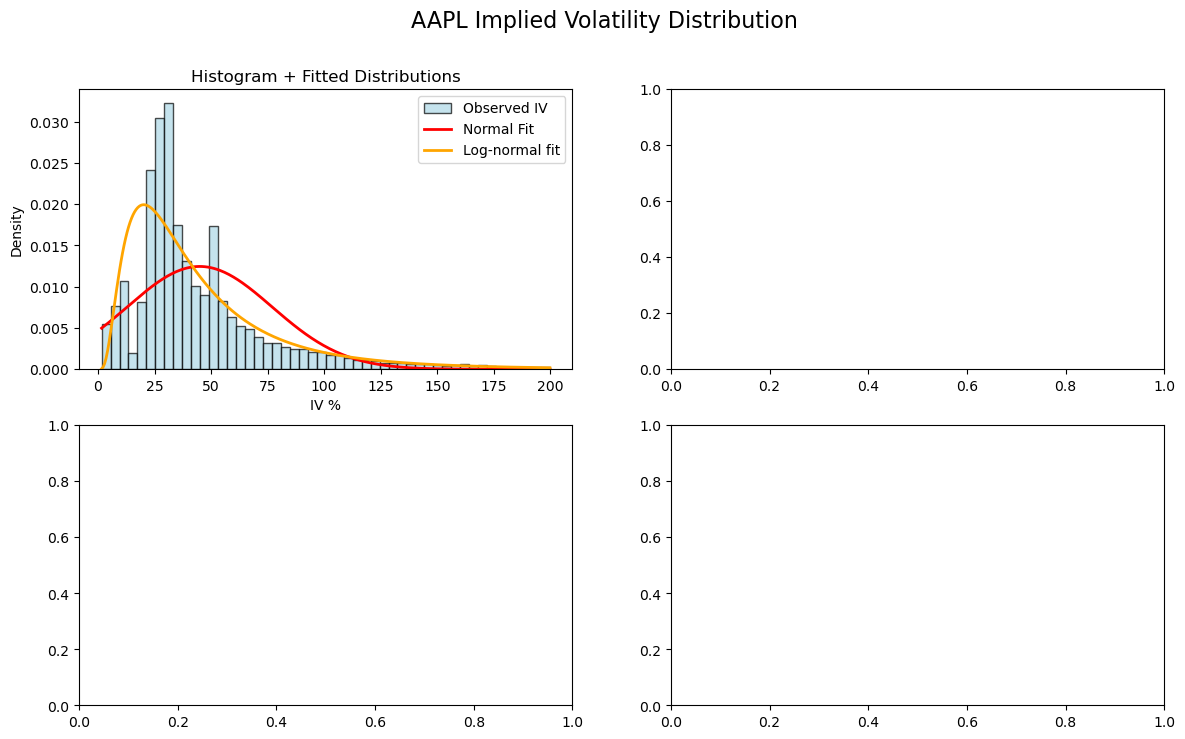

In [11]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

fig, axes=plt.subplots(2,2, figsize=(14,8))

fig.suptitle("AAPL Implied Volatility Distribution", fontsize=16)

## Chart 1 Histogram + fitted curves 

ax1=axes[0,0]

ax1.hist(iv, bins=50, density=True,color='lightblue', edgecolor='black', alpha=0.7, label='Observed IV')
mu,std=iv.mean(),iv.std()
x=np.linspace(iv.min(),iv.max(),300)
ax1.plot(x,stats.norm.pdf(x,mu,std), color='red',linewidth=2, label='Normal Fit')
shape,loc,scale=stats.lognorm.fit(iv,floc=0)
## .pdf(x, mu, std) = evaluate the normal curve at each x using our data's mean and std
## this draws the red bell curve — we EXPECT it to NOT fit because IV is right-skewed
## linewidth=2 = 2 pixel wide line so it's visible over the histogram
#Maximum Likelihood Estimation — finds parameters that make the data most probable)
## returns 3 parameters: shape (σ), loc (shift), scale (e^μ)
## floc=0 = forces location parameter to 0 — IV can't go below 0 so no shift needed
ax1.plot(x, stats.lognorm.pdf(x, shape, loc, scale), color="orange", linewidth=2, label="Log-normal fit")
ax1.set_title("Histogram + Fitted Distributions")  ## title for this specific panel
ax1.set_xlabel("IV %")                              ## x-axis label
ax1.set_ylabel("Density")                           ## y-axis label (density because density=True above)
ax1.legend()                                        ## show the legend with our three labels





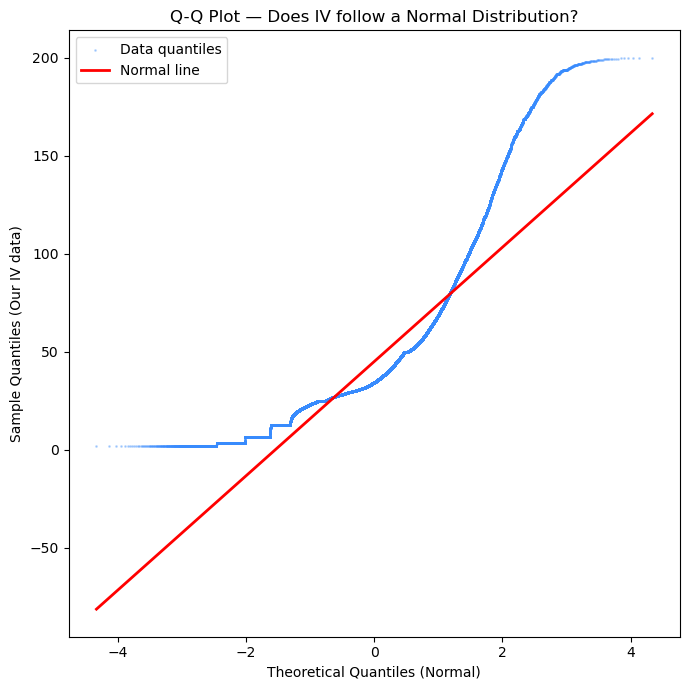

In [14]:
fig, ax = plt.subplots(figsize=(7, 7))  ## square format — Q-Q plots read better as squares

(osm, osr), (slope, intercept, r) = stats.probplot(iv, dist="norm")
## osm = theoretical quantiles from normal distribution
## osr = actual quantiles from our data
## slope/intercept = the reference diagonal line parameters

ax.scatter(osm, osr, color="#388bfd", alpha=0.3, s=1, label="Data quantiles")
## plot observed vs theoretical — if normal, these would sit on the diagonal

ax.plot(osm, slope * np.array(osm) + intercept, color="red", linewidth=2, label="Normal line")
## the diagonal reference line — points above it = heavier right tail than normal

ax.set_title("Q-Q Plot — Does IV follow a Normal Distribution?")
ax.set_xlabel("Theoretical Quantiles (Normal)")
ax.set_ylabel("Sample Quantiles (Our IV data)")
ax.legend()
plt.tight_layout()
plt.show()
                             ## show legend


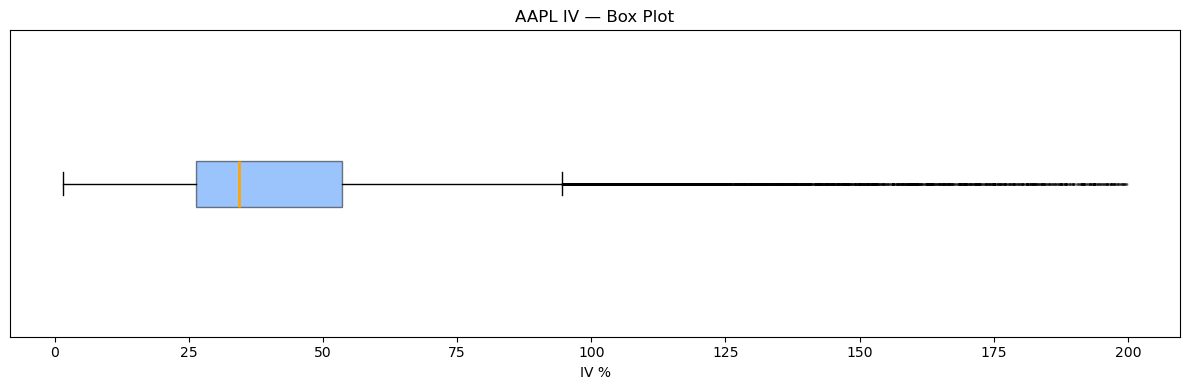

In [15]:
fig, ax = plt.subplots(figsize=(12, 4))  ## wide and short — box plots are naturally horizontal

ax.boxplot(iv, vert=False, patch_artist=True,
           boxprops=dict(facecolor="#388bfd", alpha=0.5),   ## blue filled box
           medianprops=dict(color="orange", linewidth=2),    ## orange median line
           flierprops=dict(marker=".", color="#388bfd", alpha=0.2, markersize=2))
## vert=False = horizontal orientation
## outlier dots = tiny and transparent because there are thousands of them

ax.set_title("AAPL IV — Box Plot")
ax.set_xlabel("IV %")
ax.set_yticks([])  ## remove y-axis ticks — meaningless for a single box
plt.tight_layout()
plt.show()

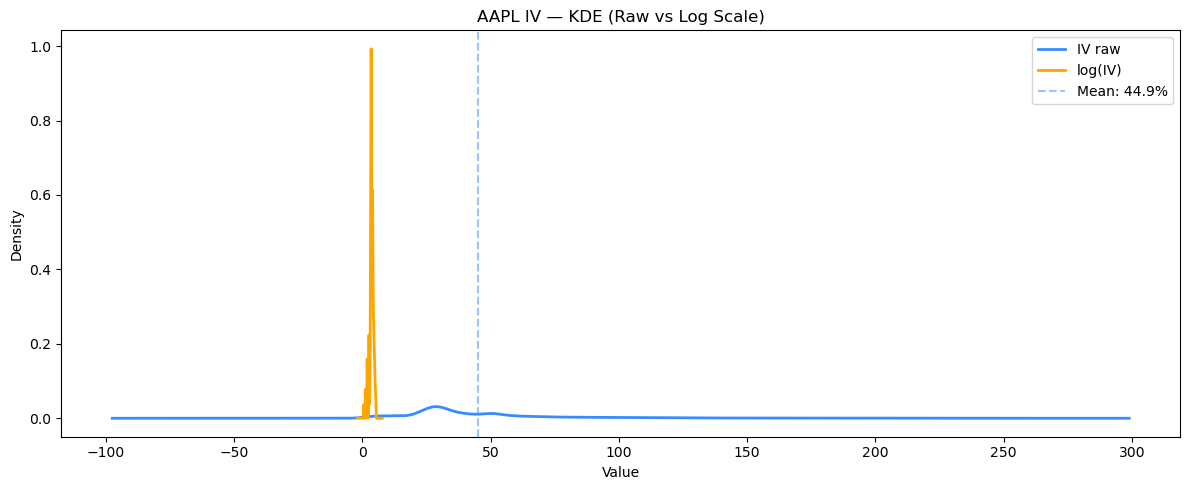

In [16]:
fig, ax = plt.subplots(figsize=(12, 5))

iv.plot.kde(ax=ax, color="#388bfd", linewidth=2, label="IV raw")
## smoothed continuous curve of raw IV — shows the true shape without bin-width bias

np.log(iv).plot.kde(ax=ax, color="orange", linewidth=2, label="log(IV)")
## log(IV) — if this looks like a symmetric bell curve, IV is log-normally distributed

ax.axvline(iv.mean(), color="#388bfd", linestyle="--", alpha=0.5, label=f"Mean: {iv.mean():.1f}%")
## vertical line at the mean so you can see where the center sits relative to the peak

ax.set_title("AAPL IV — KDE (Raw vs Log Scale)")
ax.set_xlabel("Value")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.show()

The volatility smile/skew says puts should carry higher IV than calls at the same strike and expiry. This is because:

Institutions buy puts as portfolio insurance — high demand drives up put prices → higher IV
There's more fear of a crash (left tail) than a melt-up (right tail)
Market makers charge a premium for the downside risk they're taking

The t-test will tell us whether this difference is statistically significant or could just be noise in our data.

H₀ (null hypothesis) — Call IV and Put IV have the same mean. Any difference is random.
H₁ (alternative hypothesis) — Put IV is significantly higher than Call IV.



In [18]:
df_calls = con.execute("""
    SELECT impliedVolatility * 100 AS iv
    FROM bronze_options_raw
    WHERE ticker = 'AAPL'
    AND option_type = 'call'
    AND impliedVolatility > 0.01
    AND impliedVolatility < 2.0
    AND HOUR(snapshot_time) BETWEEN 9 AND 18
""").df()["iv"].dropna()

df_puts = con.execute("""
    SELECT impliedVolatility * 100 AS iv
    FROM bronze_options_raw
    WHERE ticker = 'AAPL'
    AND option_type = 'put'
    AND impliedVolatility > 0.01
    AND impliedVolatility < 2.0
    AND HOUR(snapshot_time) BETWEEN 9 AND 18
""").df()["iv"].dropna()

print(f"Calls — n: {len(df_calls):,}  Mean IV: {df_calls.mean():.2f}%  Std: {df_calls.std():.2f}%")
print(f"Puts  — n: {len(df_puts):,}  Mean IV: {df_puts.mean():.2f}%  Std: {df_puts.std():.2f}%")
print(f"Difference in means: {df_puts.mean() - df_calls.mean():.2f}%")

Calls — n: 51,111  Mean IV: 47.34%  Std: 32.49%
Puts  — n: 44,864  Mean IV: 42.19%  Std: 31.28%
Difference in means: -5.14%


In [19]:
from scipy import stats

t_stat,p_value=stats.ttest_ind(df_calls,df_puts, equal_var=False) 
 ## Welch's t-test (unequal variance)
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value:     {p_value:.6f}")
print()


## interpret the result
if p_value < 0.05:
    print("SIGNIFICANT — reject H₀. Call IV and Put IV are statistically different.")
    print(f"Calls are {'higher' if df_calls.mean() > df_puts.mean() else 'lower'} than puts by {abs(df_calls.mean() - df_puts.mean()):.2f}%")
else:
    print("NOT SIGNIFICANT — fail to reject H₀. Difference could be random chance.")


t-statistic: 24.9638
p-value:     0.000000

SIGNIFICANT — reject H₀. Call IV and Put IV are statistically different.
Calls are higher than puts by 5.14%


 the market was pricing more uncertainty to the upside than the downside. That's consistent with a stock approaching two major catalysts (WWDC, iPhone Launch) where traders were positioned for a bullish breakout. Call demand was elevated.

In [20]:
## pull calls and puts at strikes within 5% of spot price
## joining silver_price_daily to get the actual spot at each snapshot date
## this gives us equidistant strikes — apples to apples comparison

df_near = con.execute("""
    SELECT
        b.option_type,
        b.impliedVolatility * 100 AS iv,
        b.strike,
        p.Close AS spot
    FROM bronze_options_raw b
    JOIN silver_price_daily p
        ON p.ticker = b.ticker
        AND p.Date = DATE(b.snapshot_time)  -- match price date to snapshot date
    WHERE b.ticker = 'AAPL'
    AND b.impliedVolatility > 0.01
    AND b.impliedVolatility < 2.0
    AND HOUR(b.snapshot_time) BETWEEN 9 AND 18
    AND b.strike BETWEEN p.Close * 0.95    -- no more than 5% below spot
                     AND p.Close * 1.05    -- no more than 5% above spot
""").df()

## split into calls and puts
near_calls = df_near[df_near["option_type"] == "call"]["iv"].dropna()
near_puts  = df_near[df_near["option_type"] == "put"]["iv"].dropna()

print(f"Near-ATM Calls — n: {len(near_calls):,}  Mean IV: {near_calls.mean():.2f}%  Std: {near_calls.std():.2f}%")
print(f"Near-ATM Puts  — n: {len(near_puts):,}  Mean IV: {near_puts.mean():.2f}%  Std: {near_puts.std():.2f}%")
print(f"Difference (Puts - Calls): {near_puts.mean() - near_calls.mean():.2f}%")

Near-ATM Calls — n: 5,402  Mean IV: 28.84%  Std: 10.64%
Near-ATM Puts  — n: 5,236  Mean IV: 23.07%  Std: 8.54%
Difference (Puts - Calls): -5.77%


In [21]:
t_stat, p_value = stats.ttest_ind(near_calls, near_puts, equal_var=False)

print(f"Near-ATM Calls mean:  {near_calls.mean():.2f}%")
print(f"Near-ATM Puts mean:   {near_puts.mean():.2f}%")
print(f"Difference:           {near_calls.mean() - near_puts.mean():.2f}% (calls higher)")
print()
print(f"t-statistic:  {t_stat:.4f}")
print(f"p-value:      {p_value:.6f}")
print()

if p_value < 0.05:
    print("SIGNIFICANT — the forward skew is real, not random noise")
else:
    print("NOT SIGNIFICANT — difference could be random chance")

Near-ATM Calls mean:  28.84%
Near-ATM Puts mean:   23.07%
Difference:           5.77% (calls higher)

t-statistic:  30.8963
p-value:      0.000000

SIGNIFICANT — the forward skew is real, not random noise


Near-ATM AAPL calls were priced 5.77% richer in IV than equivalent puts. The market was charging more for upside optionality than downside protection. That's a direct expression of bullish sentiment through options pricing 

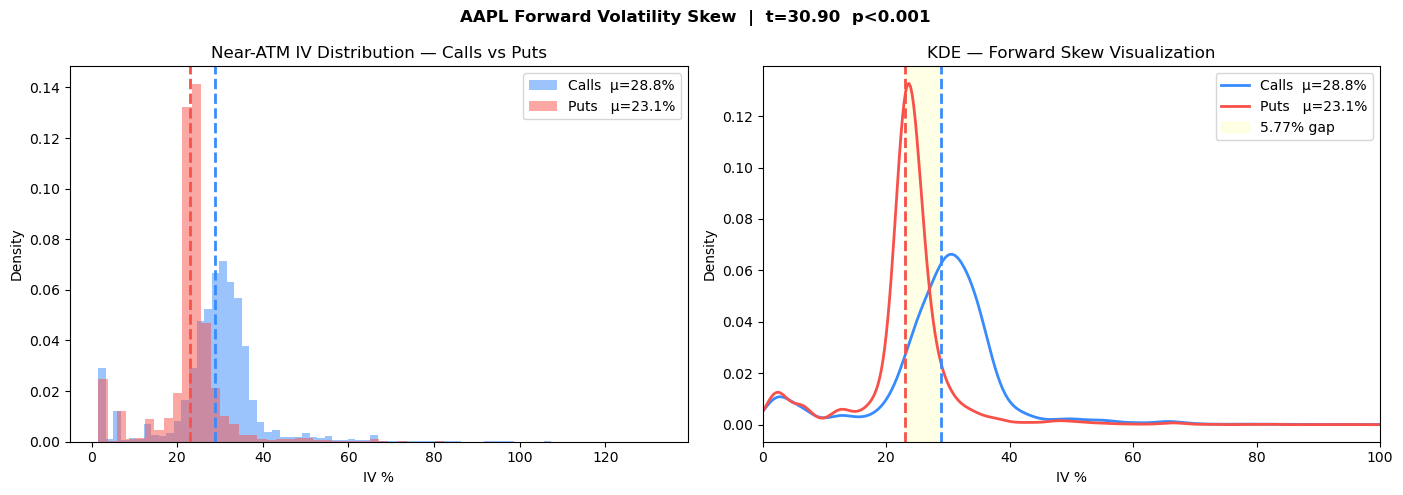

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

## ── Left: overlapping histograms ─────────────────────────────────────────────
ax1 = axes[0]
ax1.hist(near_calls, bins=60, density=True, alpha=0.5, color="#388bfd", label=f"Calls  μ={near_calls.mean():.1f}%")
ax1.hist(near_puts,  bins=60, density=True, alpha=0.5, color="#f85149", label=f"Puts   μ={near_puts.mean():.1f}%")
## vertical lines at each mean so the separation is immediately visible
ax1.axvline(near_calls.mean(), color="#388bfd", linewidth=2, linestyle="--")
ax1.axvline(near_puts.mean(),  color="#f85149", linewidth=2, linestyle="--")
ax1.set_title("Near-ATM IV Distribution — Calls vs Puts")
ax1.set_xlabel("IV %")
ax1.set_ylabel("Density")
ax1.legend()

## ── Right: KDE curves — smoother view of the same comparison ─────────────────
ax2 = axes[1]
near_calls.plot.kde(ax=ax2, color="#388bfd", linewidth=2, label=f"Calls  μ={near_calls.mean():.1f}%")
near_puts.plot.kde(ax=ax2,  color="#f85149", linewidth=2, label=f"Puts   μ={near_puts.mean():.1f}%")
ax2.axvline(near_calls.mean(), color="#388bfd", linewidth=2, linestyle="--")
ax2.axvline(near_puts.mean(),  color="#f85149", linewidth=2, linestyle="--")
## shade the gap between the two means to make the 5.77% difference visible
ax2.axvspan(near_puts.mean(), near_calls.mean(), alpha=0.1, color="yellow", label="5.77% gap")
ax2.set_title("KDE — Forward Skew Visualization")
ax2.set_xlabel("IV %")
ax2.set_ylabel("Density")
ax2.legend()

plt.suptitle(f"AAPL Forward Volatility Skew  |  t={t_stat:.2f}  p<0.001", fontweight="bold")
plt.tight_layout()
ax2.set_xlim(0, 100)  ## add this line before plt.tight_layout()
plt.show()

The t-test result (t=30.90, p<0.001) means we can state with near-certainty that the 5.77% gap between call and put IV is a structural feature of AAPL's options market during this period 
When calls carry higher IV than puts at equivalent strikes, the market is saying it sees more potential for upside movement than downside. one couls assume jabronis  were willing to pay a 5.77% premium for the right to participate in an AAPL rally versus the right to be protected from a drop.

in conlusion During the Jun-Jul 2026 collection period, AAPL's options market exhibited a statistically significant forward volatility skew, with near-ATM calls carrying 5.77% higher IV than equivalent puts, indicating the market was pricing more upside optionality than downside protection ahead of the WWDC and iPhone Launch catalysts.


In [25]:

from statsmodels.stats.weightstats import ztest

## two-sample z-test comparing near-ATM call IV vs put IV
## value=0 means H0: difference in means = 0
## alternative="two-sided" tests whether they differ in either direction
z_stat, p_value_z = ztest(near_calls, near_puts, value=0, alternative="two-sided")

print(f"Z-statistic:  {z_stat:.4f}")
print(f"p-value:      {p_value_z:.6f}")
print()

## compare directly against t-test result
print(f"T-test result: t={t_stat:.4f},  p={p_value:.6f}")
print(f"Z-test result: z={z_stat:.4f},  p={p_value_z:.6f}")
print()

if p_value_z < 0.05:
    print("SIGNIFICANT — forward skew confirmed by z-test")
    print(f"Calls carry {near_calls.mean() - near_puts.mean():.2f}% higher IV than puts near ATM")

Z-statistic:  30.7918
p-value:      0.000000

T-test result: t=30.8963,  p=0.000000
Z-test result: z=30.7918,  p=0.000000

SIGNIFICANT — forward skew confirmed by z-test
Calls carry 5.77% higher IV than puts near ATM
